# **1.Objetivo**



Este notebook apresenta os principais gráficos e conclusões do estudo
sobre inadimplência em cartões de crédito.



# **2. Exploração e limpeza dos dados**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tabela_dados = pd.read_csv('/content/Python_M10_support material.csv')

In [3]:
# Primeiro, remove o separador de milhares (ponto) e depois substitui o separador decimal (vírgula) por um ponto
tabela_dados['limite_credito'] = tabela_dados['limite_credito'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
# Converte a coluna 'limite_credito' para numérico, substituindo erros por NaN
tabela_dados['limite_credito'] = pd.to_numeric(tabela_dados['limite_credito'], errors='coerce')

# **3. Default X Salário**

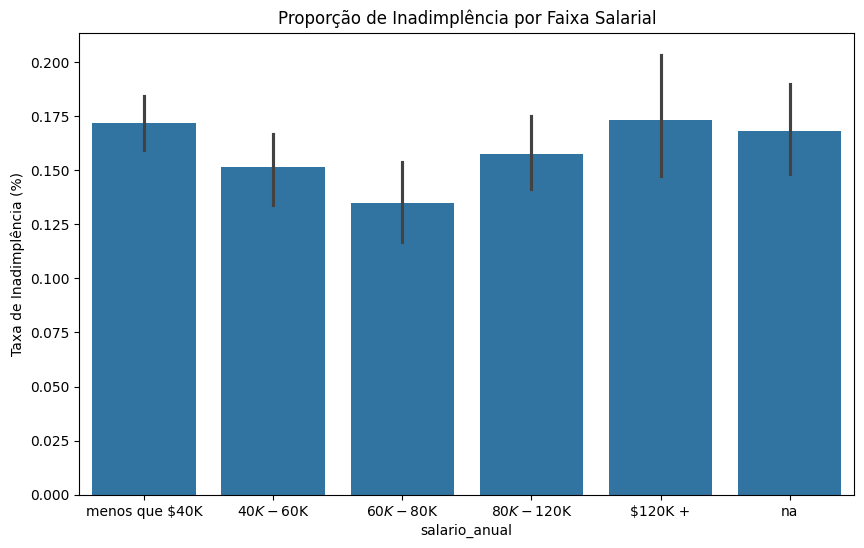

In [4]:
import seaborn as sns
# Ordenando as faixas para o gráfico ficar bonito
ordem_grafico = ['menos que $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'na']

plt.figure(figsize=(10,6))
sns.barplot(x='salario_anual', y='default', data=tabela_dados, order=ordem_grafico)
plt.title('Proporção de Inadimplência por Faixa Salarial')
plt.ylabel('Taxa de Inadimplência (%)')
plt.show()

A inadimplência apresenta um comportamento não linear em relação à renda, concentrando-se principalmente nos extremos da distribuição. Observa-se maior risco tanto entre clientes de renda mais baixa quanto entre aqueles de renda elevada, enquanto faixas intermediárias mostram maior estabilidade.
A ausência de informação salarial (“na”) também se destaca como um sinal relevante de risco, indicando que dados incompletos carregam informação importante sobre o perfil financeiro do cliente.

# **4. Default x Escolaridade x Renda**

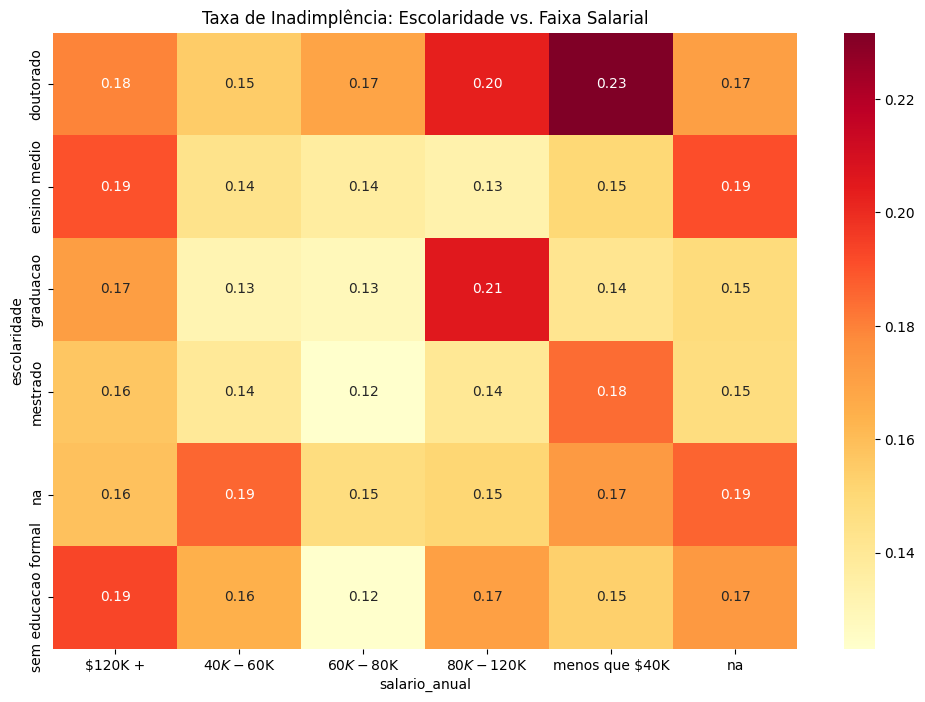

In [5]:
# Criando uma matriz para o Heatmap
pivot_table = tabela_dados.pivot_table(index='escolaridade',
                             columns='salario_anual',
                             values='default',
                             aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Taxa de Inadimplência: Escolaridade vs. Faixa Salarial')
plt.show()

A interação entre escolaridade e renda revela padrões relevantes de inadimplência. Clientes com alta escolaridade e baixa renda apresentam risco elevado, desmistificando a ideia de que maior formação acadêmica implica menor inadimplência.

Além disso, a presença de salários não informados está associada a taxas consistentemente mais altas em diferentes níveis educacionais.

# **5. Faixas de idade x Default**

In [6]:
# Definindo os cortes e as etiquetas corretamente
# Bins: [0-35], [36-46], [47-56], [57-Máximo]
bins = [0, 35, 45, 54, tabela_dados['idade'].max()]
labels = ['Até 35', '36 a 45', '46 a 54', '55+']

tabela_dados['FAIXA_ETARIA'] = pd.cut(tabela_dados['idade'], bins=bins, labels=labels)

# Verificando a distribuição
print(tabela_dados['FAIXA_ETARIA'].value_counts().sort_index())

FAIXA_ETARIA
Até 35      919
36 a 45    3742
46 a 54    3856
55+        1610
Name: count, dtype: int64


/tmp/ipykernel_38678/4288577313.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FAIXA_ETARIA', y='default', data=tabela_dados, palette='magma')


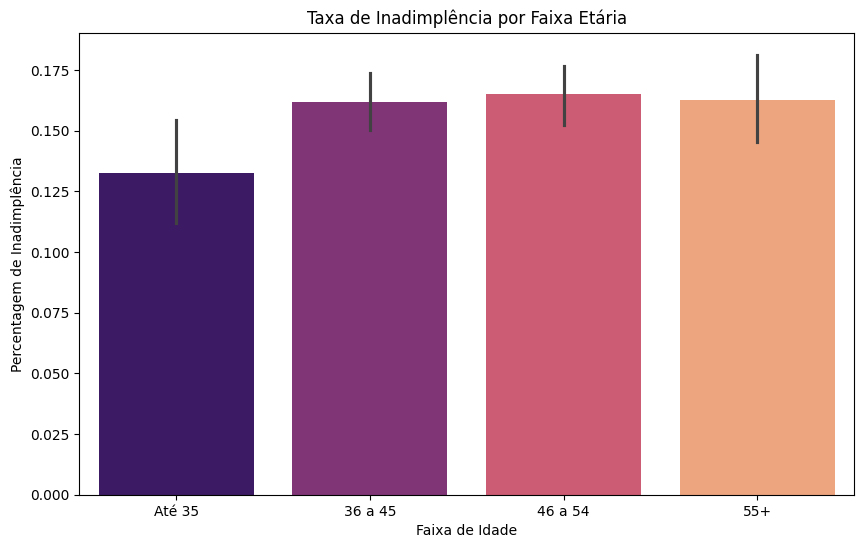

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a taxa de inadimplência por faixa
plt.figure(figsize=(10,6))
sns.barplot(x='FAIXA_ETARIA', y='default', data=tabela_dados, palette='magma')

plt.title('Taxa de Inadimplência por Faixa Etária')
plt.ylabel('Percentagem de Inadimplência')
plt.xlabel('Faixa de Idade')
plt.show()

/tmp/ipykernel_38678/30894804.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = tabela_dados.pivot_table(index='FAIXA_ETARIA',


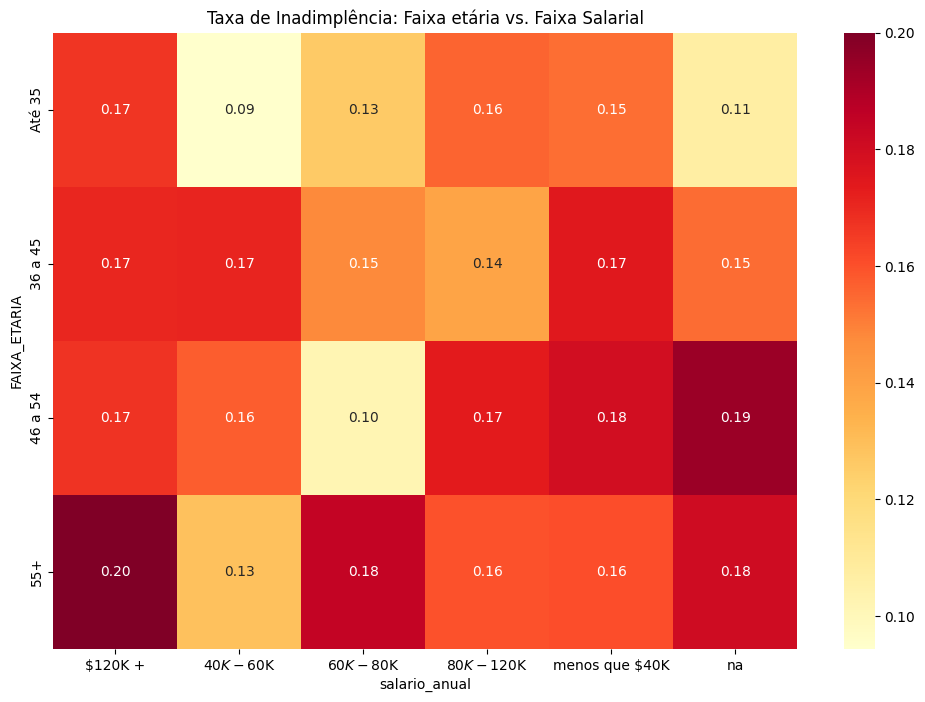

In [8]:
# Criando uma matriz para o Heatmap
pivot_table = tabela_dados.pivot_table(index='FAIXA_ETARIA',
                             columns='salario_anual',
                             values='default',
                             aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Taxa de Inadimplência: Faixa etária vs. Faixa Salarial')
plt.show()

A inadimplência aumenta com a idade, sendo mais elevada entre clientes a partir de 55 anos. Esse comportamento persiste mesmo em faixas salariais mais altas, indicando que idade e renda não atuam de forma compensatória.

Clientes mais jovens apresentam menor risco, possivelmente devido a limites mais conservadores e menor exposição ao crédito.

## **5.1 Análise de clientes na 55+ que não informaram renda x outras variáveis**

In [9]:
# Isolando o grupo de maior risco
grupo_risco = tabela_dados[(tabela_dados['FAIXA_ETARIA'] == '55+') &
                          (tabela_dados['salario_anual'] == 'na')]

print(f"Total de pessoas nesse grupo: {len(grupo_risco)}")

Total de pessoas nesse grupo: 188


In [11]:
# Verificando a escolaridade nesse grupo específico
escolaridade_risco = grupo_risco['escolaridade'].value_counts(normalize=True) * 100
print(escolaridade_risco)

escolaridade
mestrado               31.382979
ensino medio           19.680851
sem educacao formal    17.021277
na                     14.361702
graduacao               9.042553
doutorado               8.510638
Name: proportion, dtype: float64


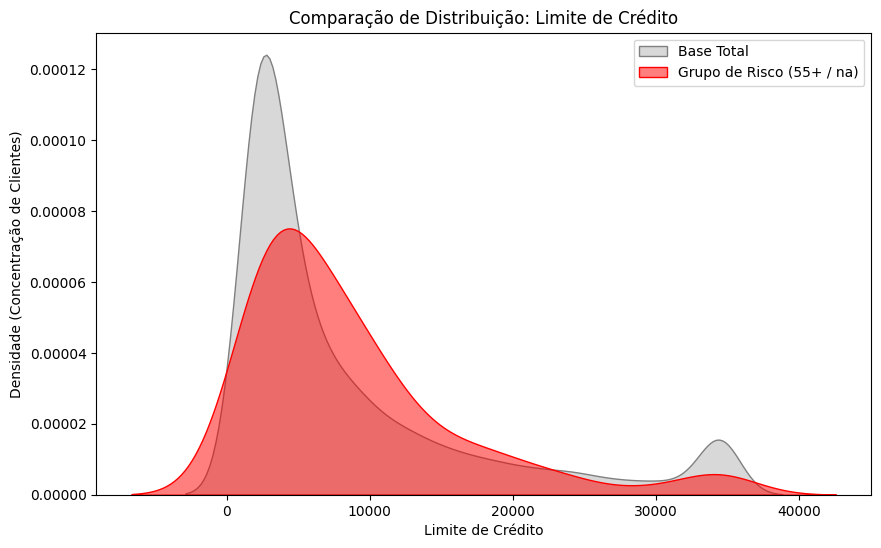

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Ensure 'limite_credito' in tabela_dados is numeric. This was handled in a previous cell
# (uTP5r61uPvKv), but we need to re-create grupo_risco to reflect this change.

# Re-create grupo_risco to ensure it uses the numeric 'limite_credito'
grupo_risco = tabela_dados[(tabela_dados['FAIXA_ETARIA'] == '55+') &
                          (tabela_dados['salario_anual'] == 'na')].copy() # .copy() to avoid SettingWithCopyWarning

# Curva da Base Total
sns.kdeplot(tabela_dados['limite_credito'], label='Base Total', fill=True, color='gray', alpha=0.3)

# Curva do Grupo de Risco
sns.kdeplot(grupo_risco['limite_credito'], label='Grupo de Risco (55+ / na)', fill=True, color='red', alpha=0.5)

plt.title('Comparação de Distribuição: Limite de Crédito')
plt.xlabel('Limite de Crédito')
plt.ylabel('Densidade (Concentração de Clientes)')
plt.legend()
plt.show()

Como esse grupo tem alta escolaridade mas um limite tão baixo, é provável que o banco já tenha identificado algum risco neles anteriormente e restringiu o crédito, ou eles são clientes novos que ainda não provaram capacidade de pagamento.

O grupo de risco está todo amontoado em limites baixos, enquanto os outros clientes estão distribuídos por valores maiores.

Média de transações deste grupo: 61.16


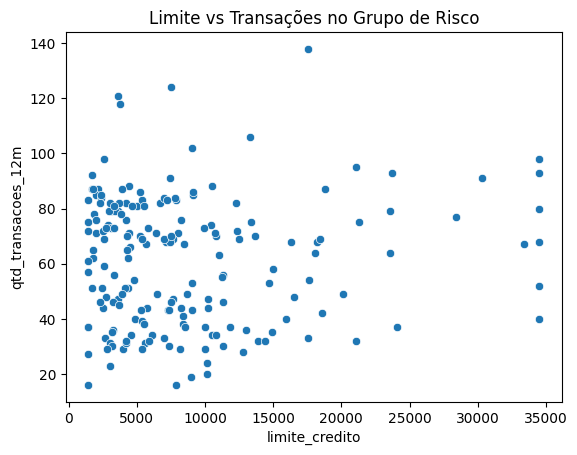

In [13]:
# Exemplo: Média de transações nos últimos 12 meses
media_transacoes = grupo_risco['qtd_transacoes_12m'].mean()
print(f"Média de transações deste grupo: {media_transacoes:.2f}")

# Verificando a relação entre limite e transações
sns.scatterplot(x='limite_credito', y='qtd_transacoes_12m', data=grupo_risco)
plt.title('Limite vs Transações no Grupo de Risco')
plt.show()

O grupo de maior risco apresenta distribuição de limites deslocada para valores mais elevados, indicando que clientes mais inadimplentes não estão necessariamente subcrédito, mas frequentemente superexpostos.

Esse padrão sugere que decisões históricas de concessão não refletem o risco atual desses clientes.

# **6. Faixa de limite**

In [14]:

# Divide em 4 grupos iguais (Quartis)
tabela_dados['FAIXA_LIMITE_QUARTIL'] = pd.qcut(tabela_dados['limite_credito'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

In [15]:
# Criando os nomes das faixas baseados nos valores reais
labels_reais = [f"R$ {int(bins[i])} - R$ {int(bins[i+1])}" for i in range(len(bins)-1)]

# Aplicando novamente com os nomes claros
tabela_dados['FAIXA_LIMITE_VALOR'] = pd.qcut(tabela_dados['limite_credito'], q=4, labels=labels_reais)

print(tabela_dados['FAIXA_LIMITE_VALOR'].value_counts())

FAIXA_LIMITE_VALOR
R$ 0 - R$ 35     2532
R$ 35 - R$ 45    2532
R$ 54 - R$ 73    2532
R$ 45 - R$ 54    2531
Name: count, dtype: int64


/tmp/ipykernel_38678/3140234668.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = tabela_dados.pivot_table(index='FAIXA_LIMITE_VALOR',


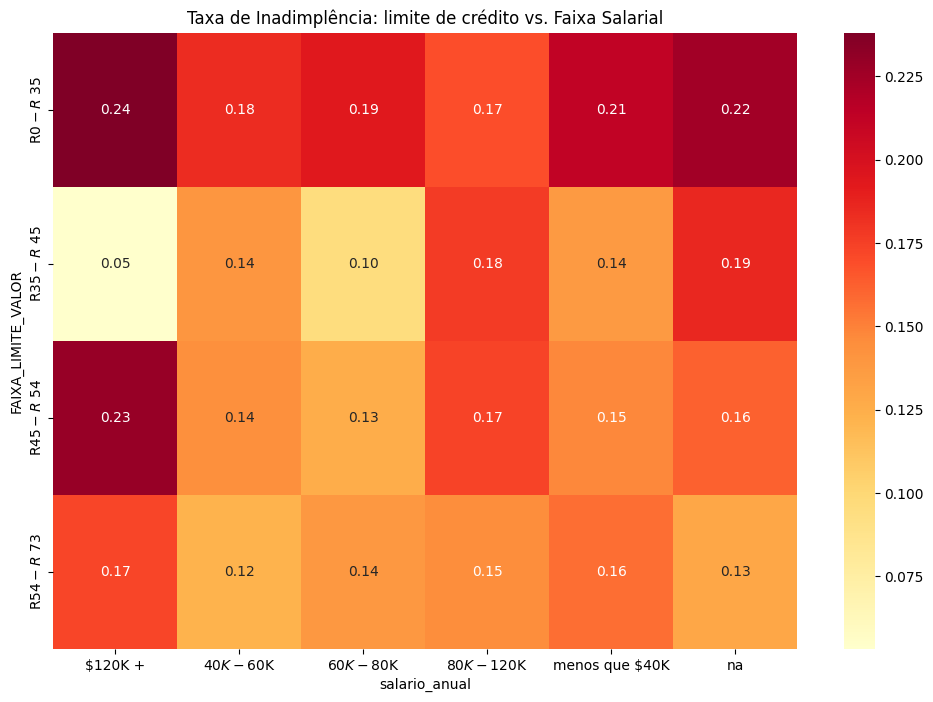

In [16]:
# Criando uma matriz para o Heatmap
pivot_table = tabela_dados.pivot_table(index='FAIXA_LIMITE_VALOR',
                             columns='salario_anual',
                             values='default',
                             aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Taxa de Inadimplência: limite de crédito vs. Faixa Salarial')
plt.show()

Clientes com limites muito baixos concentram as maiores taxas de inadimplência, independentemente da renda. Isso indica que a redução de limite ocorre, muitas vezes, após a deterioração do risco.

O menor risco ocorre quando há alinhamento entre limite concedido e capacidade financeira do cliente.

# **7. Interações x default**

In [17]:
# 1. Limpar e converter 'valor_transacoes_12m' para numérico
# Primeiro, remove o separador de milhares (ponto) e depois substitui o separador decimal (vírgula) por um ponto
tabela_dados['valor_transacoes_12m'] = tabela_dados['valor_transacoes_12m'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
# Converte a coluna para numérico, substituindo erros por NaN
tabela_dados['valor_transacoes_12m'] = pd.to_numeric(tabela_dados['valor_transacoes_12m'], errors='coerce')

# Calcular a taxa de utilização (gastos totais / limite)
# Nota: Como valor_transacoes é o acumulado de 12 meses,
# vamos dividir por 12 para ter uma média mensal e comparar com o limite.
tabela_dados['utilizacao_mensal_media'] = (tabela_dados['valor_transacoes_12m'] / 12) / tabela_dados['limite_credito']

# 2. Criar faixas de utilização para facilitar a leitura
limites_uso = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 100] # 100 para capturar casos acima do limite
labels_uso = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%', '>100%']

tabela_dados['faixa_utilizacao'] = pd.cut(tabela_dados['utilizacao_mensal_media'], bins=limites_uso, labels=labels_uso)

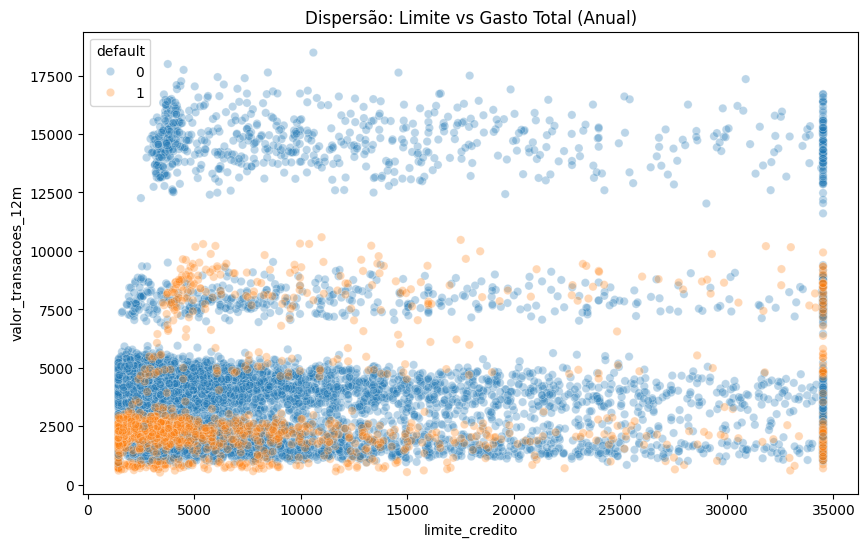

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tabela_dados, x='limite_credito', y='valor_transacoes_12m', hue='default', alpha=0.3)
plt.title('Dispersão: Limite vs Gasto Total (Anual)')
plt.show()

A inadimplência está fortemente associada ao baixo gasto anual, independentemente do limite disponível. Clientes com gasto recorrente e elevado apresentam menor risco, enquanto clientes inadimplentes tendem a usar pouco o cartão.

Isso mostra que o limite disponível não reflete, necessariamente, o comportamento financeiro real.

In [20]:
# Agrupando por número de interações e calculando a taxa de inadimplência
df_interacoes = (tabela_dados.groupby('iteracoes_12m')['default'].mean() * 100).reset_index()
df_interacoes.columns = ['Quantidade de Interações (12m)', 'Taxa de Inadimplência (%)']

# Formatando a porcentagem
df_interacoes['Taxa de Inadimplência (%)'] = df_interacoes['Taxa de Inadimplência (%)'].map('{:.2f}%'.format)


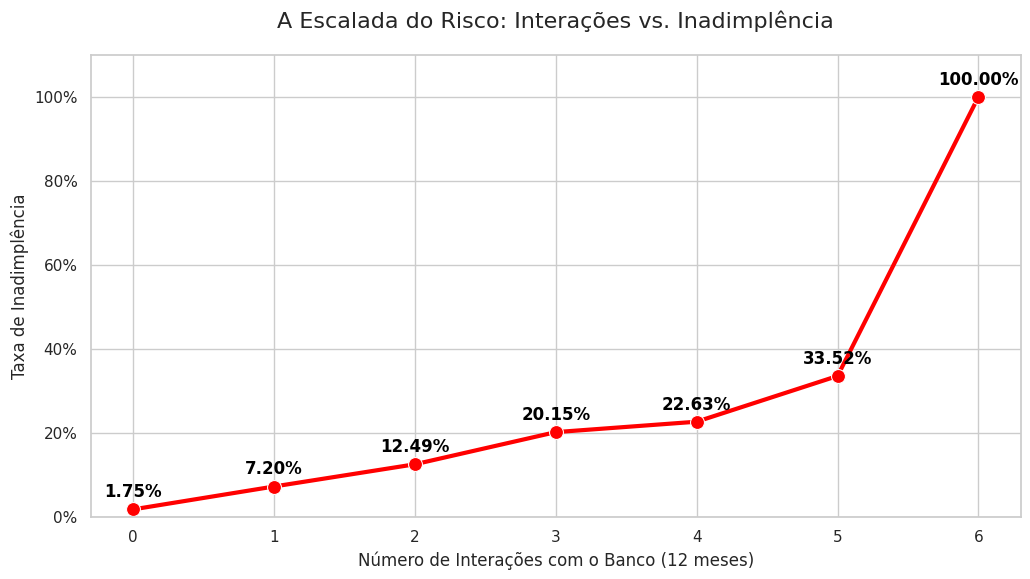

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Configurando o estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Criando o gráfico de linha para mostrar a tendência
paleta = sns.color_palette("Reds", n_colors=7)
ax = sns.lineplot(data=df_interacoes, x='Quantidade de Interações (12m)',
                  y=df_interacoes['Taxa de Inadimplência (%)'].str.replace('%','').astype(float)/100,
                  marker='o', markersize=10, color='red', linewidth=3)

# Adicionando os rótulos de porcentagem em cima de cada ponto
for i in range(df_interacoes.shape[0]):
    valor = df_interacoes['Taxa de Inadimplência (%)'].iloc[i]
    plt.text(i, float(valor.replace('%',''))/100 + 0.03, valor,
             ha='center', fontweight='bold', color='black')

# Formatando o eixo Y para porcentagem
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Títulos e legendas
plt.title('A Escalada do Risco: Interações vs. Inadimplência', fontsize=16, pad=20)
plt.xlabel('Número de Interações com o Banco (12 meses)', fontsize=12)
plt.ylabel('Taxa de Inadimplência', fontsize=12)
plt.ylim(0, 1.1) # Garante espaço para o rótulo de 100%

plt.show()

Existe uma relação direta, crescente e acelerada entre o número de interações com o banco e a inadimplência. A partir da terceira interação, o risco se eleva de forma significativa, atingindo níveis críticos nos maiores volumes de contato.

As interações funcionam como um claro indicador de estresse financeiro.